# 02 — Exploring the sensors and finding the biofilter event

This notebook explores normal behaviour, checks relationships between signals and uses a simple rolling z-score to identify unusual daily ammonia levels.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path("..").resolve()
sns.set_theme(style="whitegrid")

clean_path = PROJECT_ROOT / "data" / "ras_sensors_clean.csv"
df = pd.read_csv(clean_path, parse_dates=["timestamp"])
print(df.shape)
display(df.head())

(51840, 15)


,timestamp,tank_id,temp_c,do_mgL,ph,ammonia_mgL,turbidity_ntu,flow_Lmin,flag_logger_outage,flag_invalid_do,flag_invalid_flow,flag_stuck_ph,flag_do_drift,flag_temp_shift,flag_any_issue
0,2026-03-01 00:00:00,T1,28.26,7.39,7.24,0.164,2.6,421.9,False,False,False,False,False,False,False
1,2026-03-01 00:10:00,T1,28.18,7.40,7.25,0.194,3.0,417.2,False,False,False,False,False,False,False
2,2026-03-01 00:20:00,T1,28.26,7.42,7.23,0.158,3.0,420.4,False,False,False,False,False,False,False
3,2026-03-01 00:30:00,T1,28.26,7.25,7.23,0.165,3.3,416.0,False,False,False,False,False,False,False
4,2026-03-01 00:40:00,T1,28.10,7.40,7.25,0.168,3.3,420.7,False,False,False,False,False,False,False


## 1. Summary statistics and distributions

,count,mean,std,min,25%,50%,75%,max
temp_c,51552.0,28.560,0.504,27.540,28.210,28.490,28.820,30.220
do_mgL,51493.0,6.872,0.501,3.960,6.580,6.890,7.300,7.910
ph,51552.0,6.987,0.177,6.650,6.830,6.990,7.140,7.360
ammonia_mgL,51552.0,0.299,0.353,0.046,0.159,0.188,0.268,2.266
turbidity_ntu,51552.0,3.784,1.048,1.600,3.100,3.400,4.200,8.000
flow_Lmin,51537.0,420.602,2.725,408.900,418.800,420.600,422.500,430.800


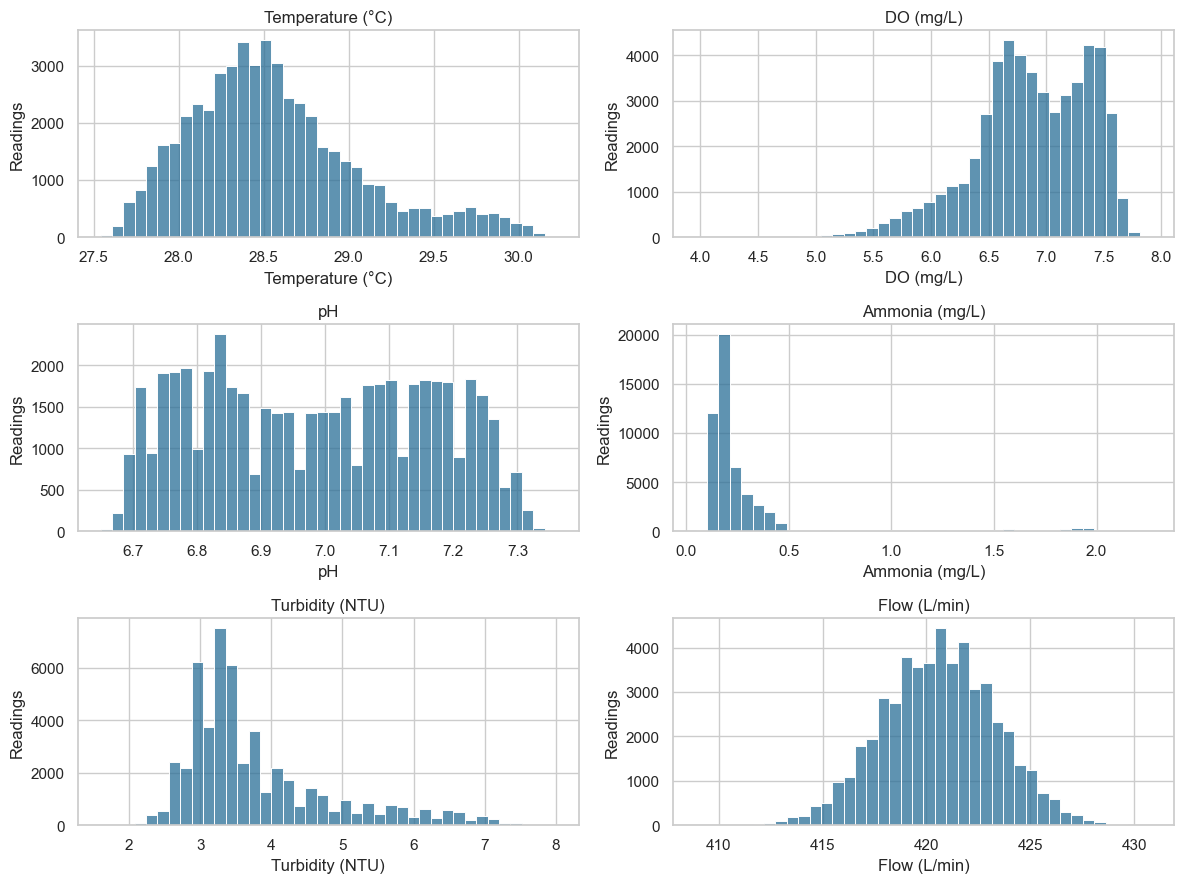

In [2]:
signals = ["temp_c", "do_mgL", "ph", "ammonia_mgL", "turbidity_ntu", "flow_Lmin"]
labels = {
    "temp_c": "Temperature (°C)", "do_mgL": "DO (mg/L)", "ph": "pH",
    "ammonia_mgL": "Ammonia (mg/L)", "turbidity_ntu": "Turbidity (NTU)",
    "flow_Lmin": "Flow (L/min)"
}
display(df[signals].describe().T.round(3))

fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for ax, signal in zip(axes.flat, signals):
    sns.histplot(df[signal], bins=40, ax=ax, color="#2a6f97")
    ax.set_title(labels[signal])
    ax.set_xlabel(labels[signal])
    ax.set_ylabel("Readings")
fig.tight_layout()
plt.show()

## 2. Plot each signal over time

Daily medians make the 90-day period easier to read. The charts show both local sensor problems and a system-wide ammonia increase near the end of April.

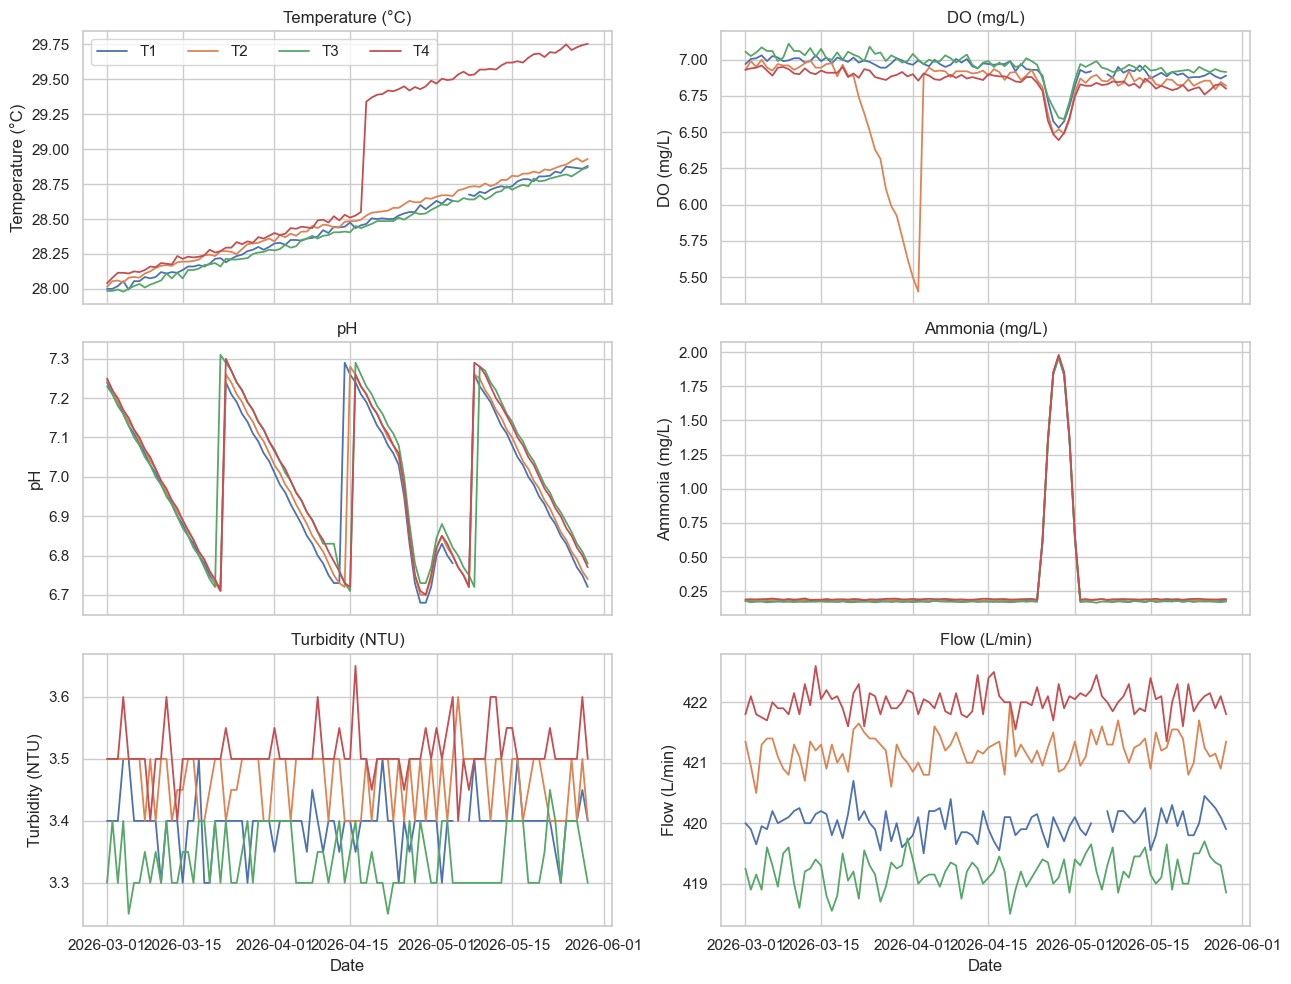

In [3]:
daily_tank = (
    df.set_index("timestamp").groupby("tank_id")[signals].resample("D").median().reset_index()
)

fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)
for ax, signal in zip(axes.flat, signals):
    for tank, group in daily_tank.groupby("tank_id"):
        ax.plot(group["timestamp"], group[signal], label=tank, linewidth=1.3)
    ax.set_title(labels[signal])
    ax.set_ylabel(labels[signal])
axes[0, 0].legend(ncol=4)
axes[-1, 0].set_xlabel("Date")
axes[-1, 1].set_xlabel("Date")
fig.tight_layout()
plt.show()

## 3. Check the feeding cycle

I group normal readings by time of day. The vertical lines show feeding at 08:00, 13:00 and 18:00. Ammonia rises after each feed while dissolved oxygen falls.

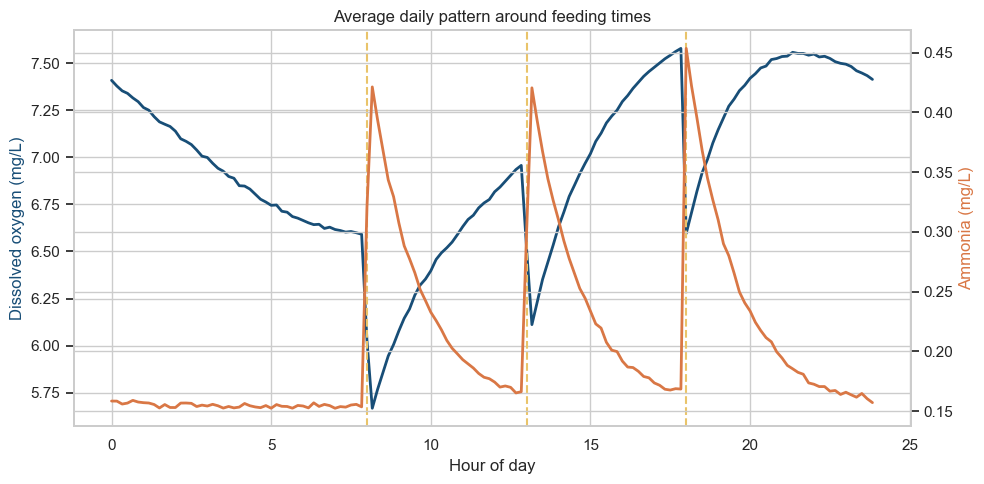

In [4]:
normal_cutoff = df["timestamp"].min() + pd.Timedelta(days=45)
normal = df[(df["timestamp"] < normal_cutoff) & ~df["flag_any_issue"]].copy()
normal["hour"] = normal["timestamp"].dt.hour + normal["timestamp"].dt.minute / 60
by_hour = normal.groupby("hour")[["do_mgL", "ammonia_mgL"]].mean()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(by_hour.index, by_hour["do_mgL"], color="#184e77", linewidth=2, label="DO")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Dissolved oxygen (mg/L)", color="#184e77")
ax2 = ax1.twinx()
ax2.plot(by_hour.index, by_hour["ammonia_mgL"], color="#d97745", linewidth=2, label="Ammonia")
ax2.set_ylabel("Ammonia (mg/L)", color="#d97745")
for feed_time in [8, 13, 18]:
    ax1.axvline(feed_time, color="#e9c46a", linestyle="--")
ax1.set_title("Average daily pattern around feeding times")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "images" / "daily_cycle.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Look at correlations

Correlation does not prove cause, but it helps check whether the relationships in the data make sense. Ammonia and turbidity rise together after feeding, while DO moves in the opposite direction.

,temp_c,do_mgL,ph,ammonia_mgL,turbidity_ntu,flow_Lmin
temp_c,1.00,0.68,-0.19,-0.05,-0.05,0.06
do_mgL,0.68,1.00,0.03,-0.50,-0.49,-0.04
ph,-0.19,0.03,1.00,-0.00,0.00,-0.03
ammonia_mgL,-0.05,-0.50,-0.00,1.00,0.93,0.03
turbidity_ntu,-0.05,-0.49,0.00,0.93,1.00,0.02
flow_Lmin,0.06,-0.04,-0.03,0.03,0.02,1.00


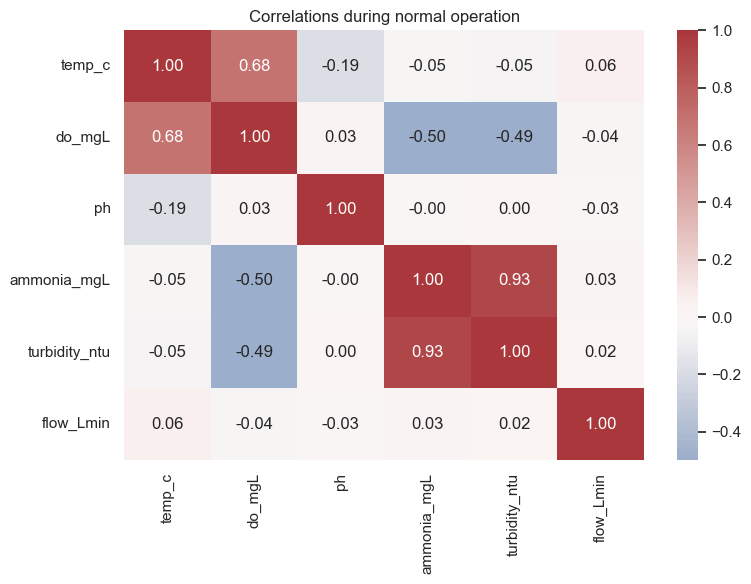

In [5]:
correlation = normal[signals].corr()
display(correlation.round(2))
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlations during normal operation")
plt.tight_layout()
plt.show()

## 5. Use a rolling z-score to find unusual ammonia

I calculate the daily median across all tanks. Each day is compared with the previous 21 days. A z-score above 3 means the value is more than three recent standard deviations above the rolling average.

This is a simple and explainable first method. I would try more complex models only after understanding this baseline.

The extreme first z-score reflects the very low variance before the event. Its magnitude is therefore not a useful severity measure; I use the z-score only as a detector for crossing the threshold.

For the event end, I keep the pre-event three-standard-deviation threshold fixed at the alert date. If I recalculated it each day, the rolling window would absorb the incident and the z-score would fall below 3 before ammonia had actually recovered.

In [6]:
df["date"] = df["timestamp"].dt.floor("D")
system_daily = df.groupby("date")[["ammonia_mgL", "ph", "do_mgL"]].median()

rolling_mean = system_daily["ammonia_mgL"].rolling(21, min_periods=14).mean().shift(1)
rolling_std = system_daily["ammonia_mgL"].rolling(21, min_periods=14).std(ddof=0).shift(1)
system_daily["ammonia_zscore"] = (
    (system_daily["ammonia_mgL"] - rolling_mean) / rolling_std
)
system_daily["ammonia_alert"] = system_daily["ammonia_zscore"] > 3

alerts = system_daily[system_daily["ammonia_alert"]]
display(alerts[["ammonia_mgL", "ammonia_zscore"]].round(2))
event_start = alerts.index.min()

# Freeze the pre-event threshold at the alert date. A recalculated rolling
# threshold would adapt to the incident and signal recovery too early.
event_threshold = rolling_mean.loc[event_start] + 3 * rolling_std.loc[event_start]
remains_high = system_daily.loc[event_start:, "ammonia_mgL"] > event_threshold
event_end = remains_high.index[~remains_high].min()
if pd.isna(event_end):
    event_end = system_daily.index.max() + pd.Timedelta(days=1)

print(f"Frozen event threshold: {event_threshold:.3f} mg/L")
print("Detected event window:", event_start.date(), "to", event_end.date())

,ammonia_mgL,ammonia_zscore
date,,
2026-04-25,0.62,294.12
2026-04-26,1.35,12.37
2026-04-27,1.85,6.11
2026-04-28,1.97,3.83


Frozen event threshold: 0.187 mg/L
Detected event window: 2026-04-25 to 2026-05-02


## 6. Check whether the other signals support the alert

Ammonia alone could be a sensor problem. During the same dates, pH and DO also fall. Because the pattern appears across all tanks and the direction makes process sense, I treat it as a real biofilter event rather than a single faulty instrument.

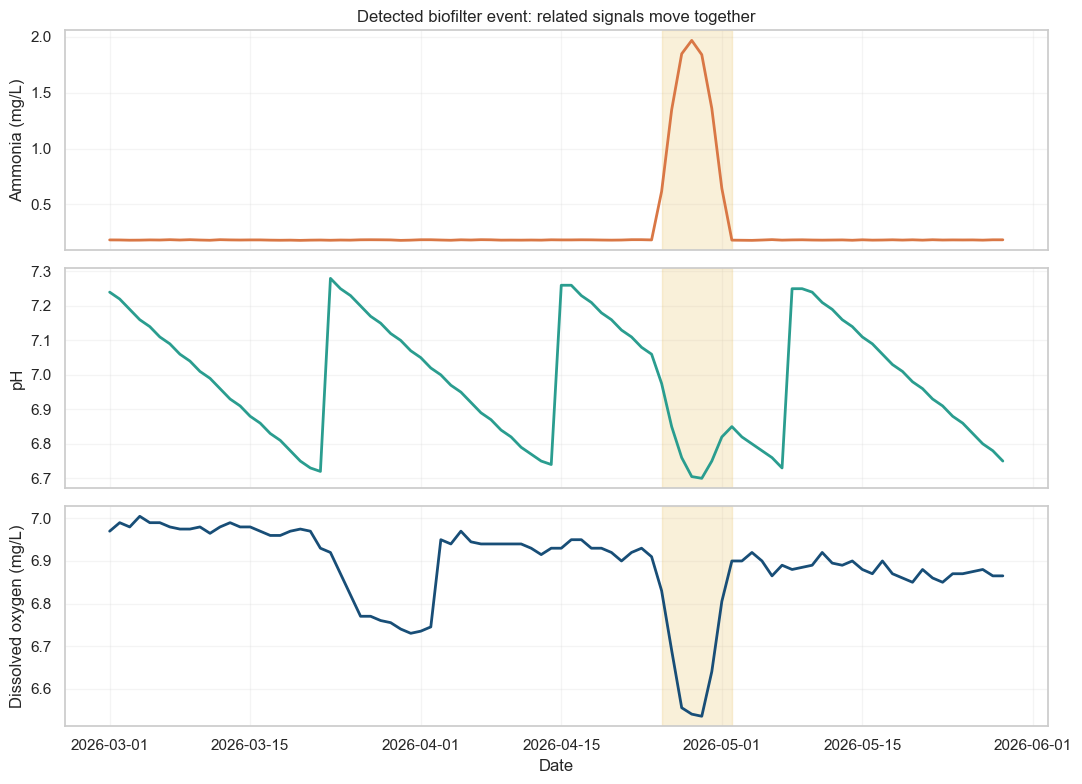

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
chart_info = [
    ("ammonia_mgL", "Ammonia (mg/L)", "#d97745"),
    ("ph", "pH", "#2a9d8f"),
    ("do_mgL", "Dissolved oxygen (mg/L)", "#184e77"),
]
for ax, (signal, label, colour) in zip(axes, chart_info):
    ax.plot(system_daily.index, system_daily[signal], color=colour, linewidth=2)
    ax.axvspan(event_start, event_end, color="#e9c46a", alpha=0.25)
    ax.set_ylabel(label)
    ax.grid(alpha=0.2)
axes[0].set_title("Detected biofilter event: related signals move together")
axes[-1].set_xlabel("Date")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "images" / "event_detection.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Score the finished work against held-back truth

This is the first and only point where the truth file is loaded. It has not influenced cleaning thresholds, event dates or the rolling baseline. The file is listed in `.gitignore`, so the answer key is not published.

I count a fault category as detected when at least 80% of its affected rows overlap my flag. The event is scored separately.

In [8]:
truth_path = PROJECT_ROOT / "data" / "ras_sensors_truth.csv"

if truth_path.exists():
    truth = pd.read_csv(truth_path, parse_dates=["timestamp"])
    raw_score = pd.read_csv(
        PROJECT_ROOT / "data" / "ras_sensors_dirty.csv",
        parse_dates=["timestamp"]
    )

    original_labels = raw_score["tank_id"].copy()
    raw_score["tank_id"] = (
        raw_score["tank_id"].str.strip().str.upper()
        .str.replace(r"^TANK", "T", regex=True)
    )
    changed_label_count = int((original_labels != raw_score["tank_id"]).sum())
    duplicate_mask = raw_score.duplicated(
        ["timestamp", "tank_id", *signals], keep="first"
    )
    duplicate_count = int(duplicate_mask.sum())

    observed = raw_score.loc[~duplicate_mask].copy()
    score_columns = [
        "timestamp", "tank_id", "flag_invalid_do", "flag_invalid_flow",
        "flag_logger_outage", "flag_stuck_ph", "flag_do_drift", "flag_temp_shift"
    ]
    scored = (
        observed.merge(truth, on=["timestamp", "tank_id"], suffixes=("_obs", "_truth"))
        .merge(df[score_columns], on=["timestamp", "tank_id"])
    )

    ammonia_change = scored["ammonia_mgL_obs"] - scored["ammonia_mgL_truth"]
    ph_change = scored["ph_obs"] - scored["ph_truth"]
    do_change = scored["do_mgL_obs"] - scored["do_mgL_truth"]
    temp_change = scored["temp_c_obs"] - scored["temp_c_truth"]

    actual_event = (ammonia_change > 0.02) & (ph_change < -0.01) & (do_change < -0.01)
    predicted_event = (
        scored["timestamp"].ge(event_start)
        & scored["timestamp"].lt(event_end)
    )

    actual_faults = {
        "DO point glitches": (
            (scored["do_mgL_obs"] < 0.5) | (scored["do_mgL_obs"] > 15)
        ),
        "Negative flow": scored["flow_Lmin_obs"] < 0,
        "Logger outage": scored[[f"{s}_obs" for s in signals]].isna().all(axis=1),
        "Stuck pH": (ph_change.abs() > 0.011) & ~actual_event,
        "Temperature shift": temp_change.abs() > 0.011,
        "DO probe drift": (
            (do_change.abs() > 0.011)
            & ~actual_event
            & scored["do_mgL_obs"].between(0.5, 15)
        ),
    }
    predicted_faults = {
        "DO point glitches": scored["flag_invalid_do"],
        "Negative flow": scored["flag_invalid_flow"],
        "Logger outage": scored["flag_logger_outage"],
        "Stuck pH": scored["flag_stuck_ph"],
        "Temperature shift": scored["flag_temp_shift"],
        "DO probe drift": scored["flag_do_drift"],
    }

    score_rows = [
        {"category": "Malformed labels", "actual_rows": changed_label_count,
         "detected_rows": changed_label_count, "recall": 1.0},
        {"category": "Duplicate rows", "actual_rows": duplicate_count,
         "detected_rows": duplicate_count, "recall": 1.0},
    ]

    for category, actual in actual_faults.items():
        predicted = predicted_faults[category]
        actual_rows = int(actual.sum())
        detected_rows = int((actual & predicted).sum())
        score_rows.append({
            "category": category,
            "actual_rows": actual_rows,
            "detected_rows": detected_rows,
            "recall": detected_rows / actual_rows,
        })

    fault_score = pd.DataFrame(score_rows)
    fault_score["category_detected"] = fault_score["recall"] >= 0.80
    display(fault_score.style.format({"recall": "{:.1%}"}))

    event_recall = (actual_event & predicted_event).sum() / actual_event.sum()
    print(f"Fault categories detected: {fault_score['category_detected'].sum()}/{len(fault_score)}")
    print(f"Process event recovered: {event_recall:.1%} of affected rows")
else:
    print("Held-back truth is not included in the public repository.")
    print("Place it at data/ras_sensors_truth.csv to reproduce this final score.")

,category,actual_rows,detected_rows,recall,category_detected
0,Malformed labels,7,7,100.0%,True
1,Duplicate rows,25,25,100.0%,True
2,DO point glitches,59,59,100.0%,True
3,Negative flow,15,15,100.0%,True
4,Logger outage,288,288,100.0%,True
5,Stuck pH,317,315,99.4%,True
6,Temperature shift,6048,6048,100.0%,True
7,DO probe drift,1887,1581,83.8%,True


Fault categories detected: 8/8
Process event recovered: 100.0% of affected rows


## Main conclusion

The rolling z-score found the start of the biofilter event on 25 April 2026. The supporting charts showed that ammonia increased while pH and DO decreased across the system.

This was different from the sensor faults found in notebook 1: those affected one tank or one measurement. Looking for agreement between related signals helped separate a real process change from bad data.

## Practical next steps

- Review high ammonia when it is supported by falling pH or DO across several tanks.
- Keep separate alerts for missing data, impossible values and flat sensors.
- Check alerts against feeding, maintenance and operator logs.
- Test the thresholds on more data before using them in a real system.